#  Install

In [ ]:
!pip install -q ultralytics roboflow pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.4 MB/s eta 0:00:00


# Imports

In [ ]:
import os, glob, yaml, shutil
from collections import Counter, defaultdict
from getpass import getpass
import matplotlib.pyplot as plt
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


# Download dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jTk8dIK2yV29fJ2Sod0a")
project = rf.workspace("fatema-yusuf").project("basma_data-31mu8")
version = project.version(4)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BASMA_DATA-4 in yolo26:: 100%|██████████| 19197/19197 [00:03<00:00, 6136.84it/s]


In [ ]:
DATASET_DIR = dataset.location
yaml_path = os.path.join(DATASET_DIR, "data.yaml")

print(DATASET_DIR)

/content/BASMA_DATA-4


# Check classes

In [ ]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

['Clapping', 'Facing-Forward', 'Hand-Raising', 'Reading', 'Sleeping', 'Talking', 'Using-Phone', 'Writing']


# Dataset counts

In [ ]:
for split in ["train", "valid", "test"]:
    print(split, ":", len(glob.glob(f"{DATASET_DIR}/{split}/images/*")))

train : 8409
valid : 794
test : 393


# Object counts

In [ ]:

def names_list(names):
    if isinstance(names, dict):
        return [names.get(i, names.get(str(i))) for i in range(len(names))]
    return list(names)

class_list = names_list(class_names)
class_counts = Counter()
images_per_class = defaultdict(set)
total_images = 0

for split in ["train", "valid", "test"]:
    total_images += len(glob.glob(f"{DATASET_DIR}/{split}/images/*"))

    for label_file in glob.glob(f"{DATASET_DIR}/{split}/labels/*.txt"):
        seen = set()

        for line in open(label_file):
            parts = line.split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[cid] += 1
            seen.add(cid)

        for cid in seen:
            images_per_class[cid].add(label_file)

total_objects = sum(class_counts.values())

print("Total images:", total_images)
print("Total objects:", total_objects)
print("Average objects/image:", round(total_objects / total_images, 2))

for i, name in enumerate(class_list):
    print(f"{name}: {class_counts[i]} objects | {len(images_per_class[i])} images")

Total images: 9596
Total objects: 12940
Average objects/image: 1.35
Clapping: 2800 objects | 1205 images
Facing-Forward: 1200 objects | 1200 images
Hand-Raising: 1775 objects | 1195 images
Reading: 1435 objects | 1206 images
Sleeping: 1254 objects | 1202 images
Talking: 1706 objects | 1207 images
Using-Phone: 1329 objects | 1200 images
Writing: 1441 objects | 1204 images


# Class chart

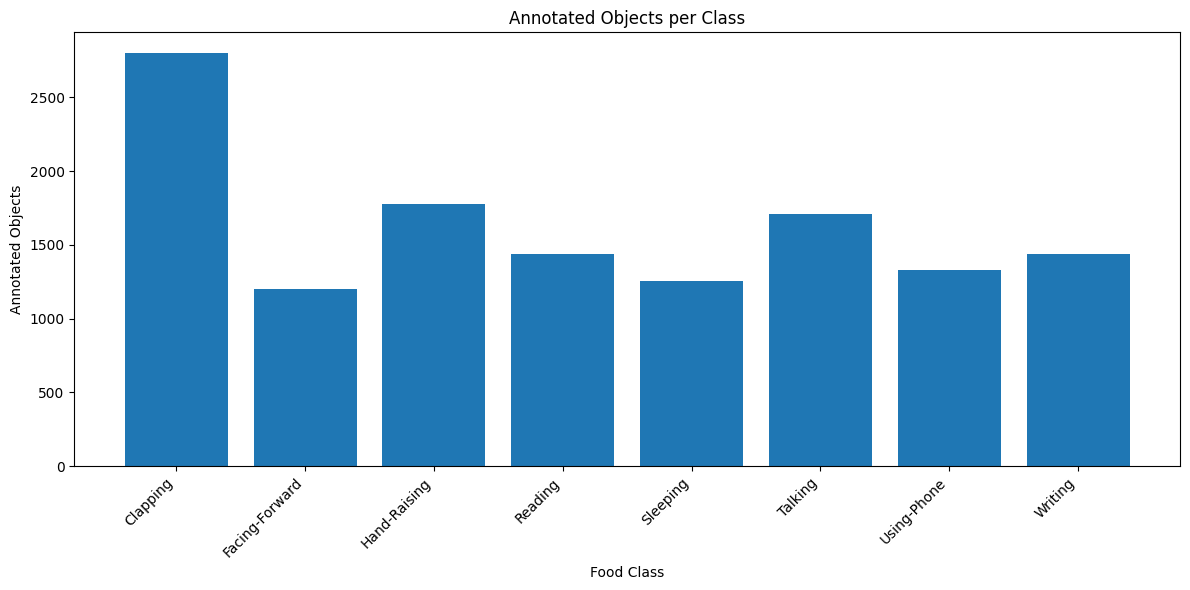

In [ ]:
counts = [class_counts[i] for i in range(len(class_list))]

plt.figure(figsize=(12, 6))
plt.bar(class_list, counts)
plt.xlabel("Food Class")
plt.ylabel("Annotated Objects")
plt.title("Annotated Objects per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Baseline


image 1/1 /content/BASMA_DATA-4/test/images/hand03_rgb_1_frame20_png_jpg.rf.8993b8d1543b0b075fe2d758521289b2.jpg: 640x640 1 person, 17.9ms
Speed: 85.0ms preprocess, 17.9ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


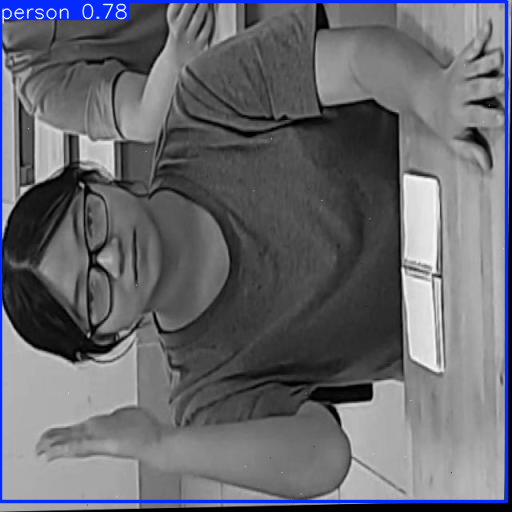

In [ ]:
model = YOLO("yolo26n.pt")

test_images = glob.glob(f"{DATASET_DIR}/test/images/*")
if not test_images:
    raise ValueError("No test images found.")

baseline = model(test_images[0])
baseline[0].show()

# Train with early stopping

In [ ]:
shutil.rmtree("/content/runs/detect/val-2", ignore_errors=True)

model = YOLO("yolo26n.pt")

model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=8,
    patience=15,
    project="/content/runs/detect",
    name="val-2"
)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BASMA_DATA-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=val-2, nbs=64, nms=False, opse

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79ea2aa939a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

# Load best model

In [ ]:
best_path = "/content/runs/detect/val-2/weights/best.pt"
v1_model = YOLO(best_path)
print(v1_model.names)

{0: 'Clapping', 1: 'Facing-Forward', 2: 'Hand-Raising', 3: 'Reading', 4: 'Sleeping', 5: 'Talking', 6: 'Using-Phone', 7: 'Writing'}


# Evaluate

In [ ]:
metrics = v1_model.val(data=yaml_path, split="test")

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 640.0±385.3 MB/s, size: 25.2 KB)
val: Scanning /content/BASMA_DATA-4/test/labels... 393 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 393/393 2.1Kit/s 0.2s
val: New cache created: /content/BASMA_DATA-4/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.4it/s 7.4s
                   all        393        538      0.766      0.712      0.742      0.412
              Clapping         48        108      0.687      0.602      0.646      0.246
        Facing-Forward         50         50      0.968          1      0.995      0.695
          Hand-Raising         50         88      0.881      0.674      0.802      0.435
               Reading         48         54      0.697      0.759      0.

# Per-class mAP50-95

In [ ]:
for name, score in zip(v1_model.names.values(), metrics.box.maps):
    print(name, ":", round(float(score), 4))

Clapping : 0.2459
Facing-Forward : 0.695
Hand-Raising : 0.4351
Reading : 0.5876
Sleeping : 0.6122
Talking : 0.1164
Using-Phone : 0.4202
Writing : 0.1865


# Test images


0: 640x640 1 Hand-Raising, 4.8ms
1: 640x640 1 Using-Phone, 4.8ms
2: 640x640 1 Facing-Forward, 4.8ms
3: 640x640 1 Sleeping, 4.8ms
4: 640x640 (no detections), 4.8ms
5: 640x640 1 Hand-Raising, 4.8ms
6: 640x640 1 Sleeping, 4.8ms
7: 640x640 1 Writing, 4.8ms
8: 640x640 1 Using-Phone, 4.8ms
9: 640x640 1 Talking, 4.8ms
Speed: 3.3ms preprocess, 4.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


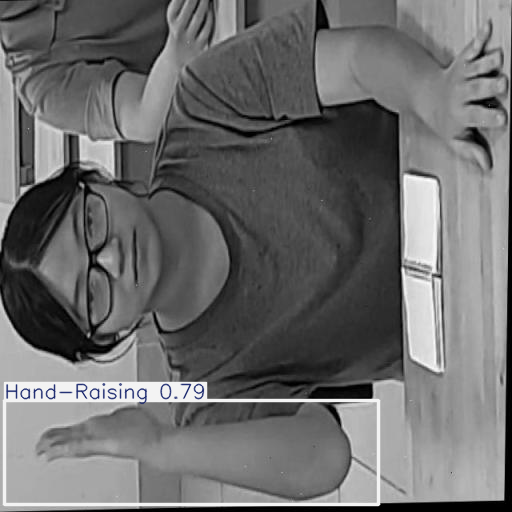

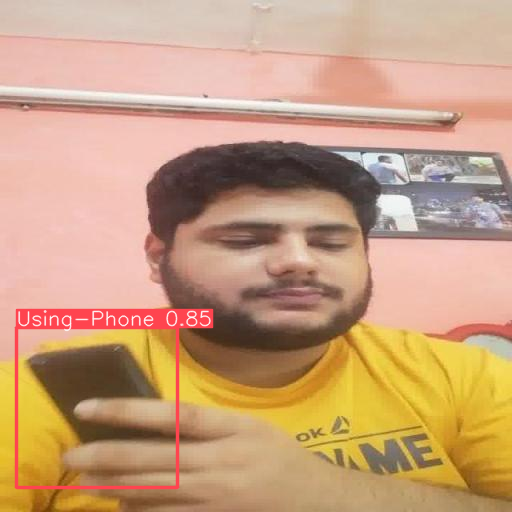

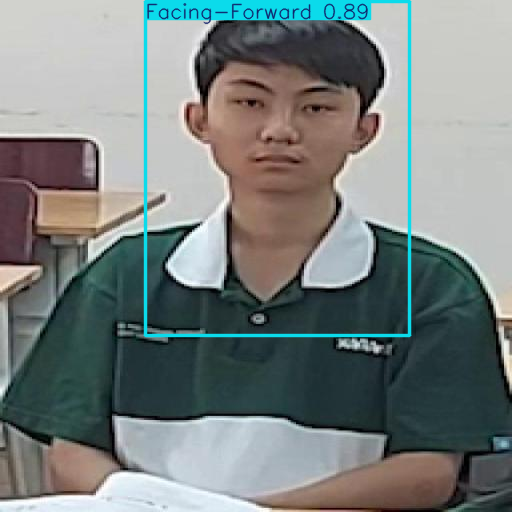

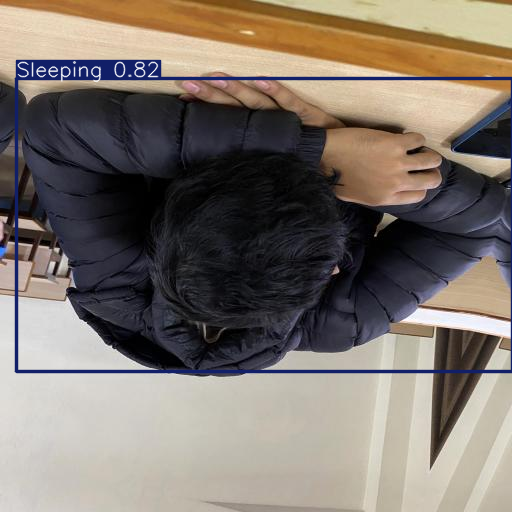

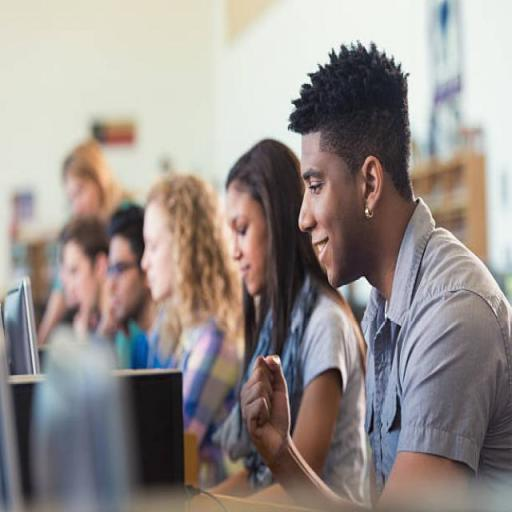

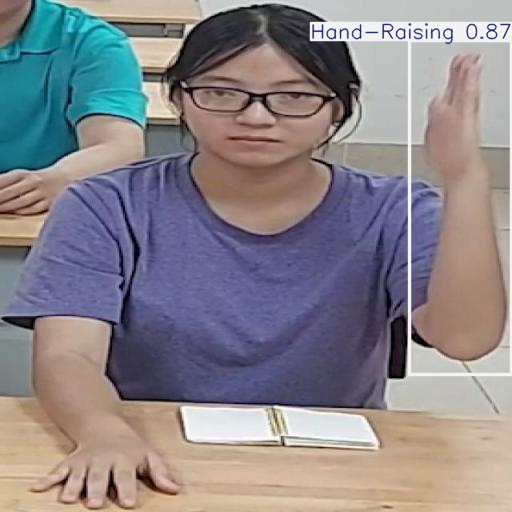

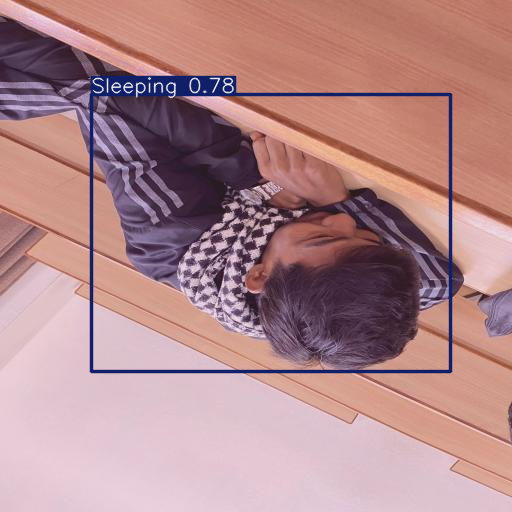

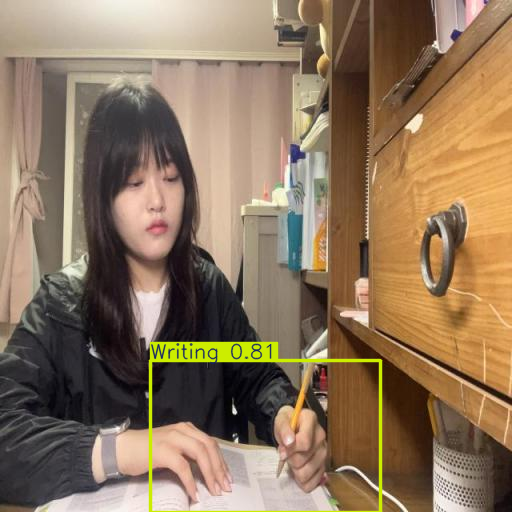

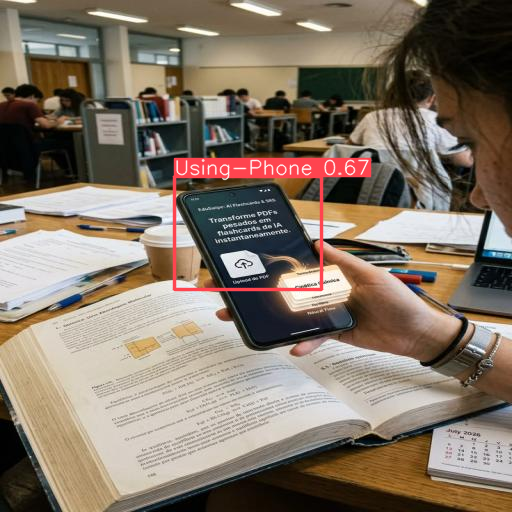

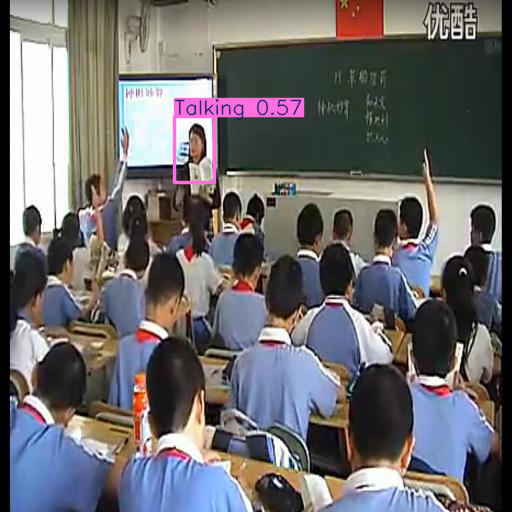

In [ ]:
results = v1_model(test_images[:10], conf=0.25)

for result in results:
    result.show()

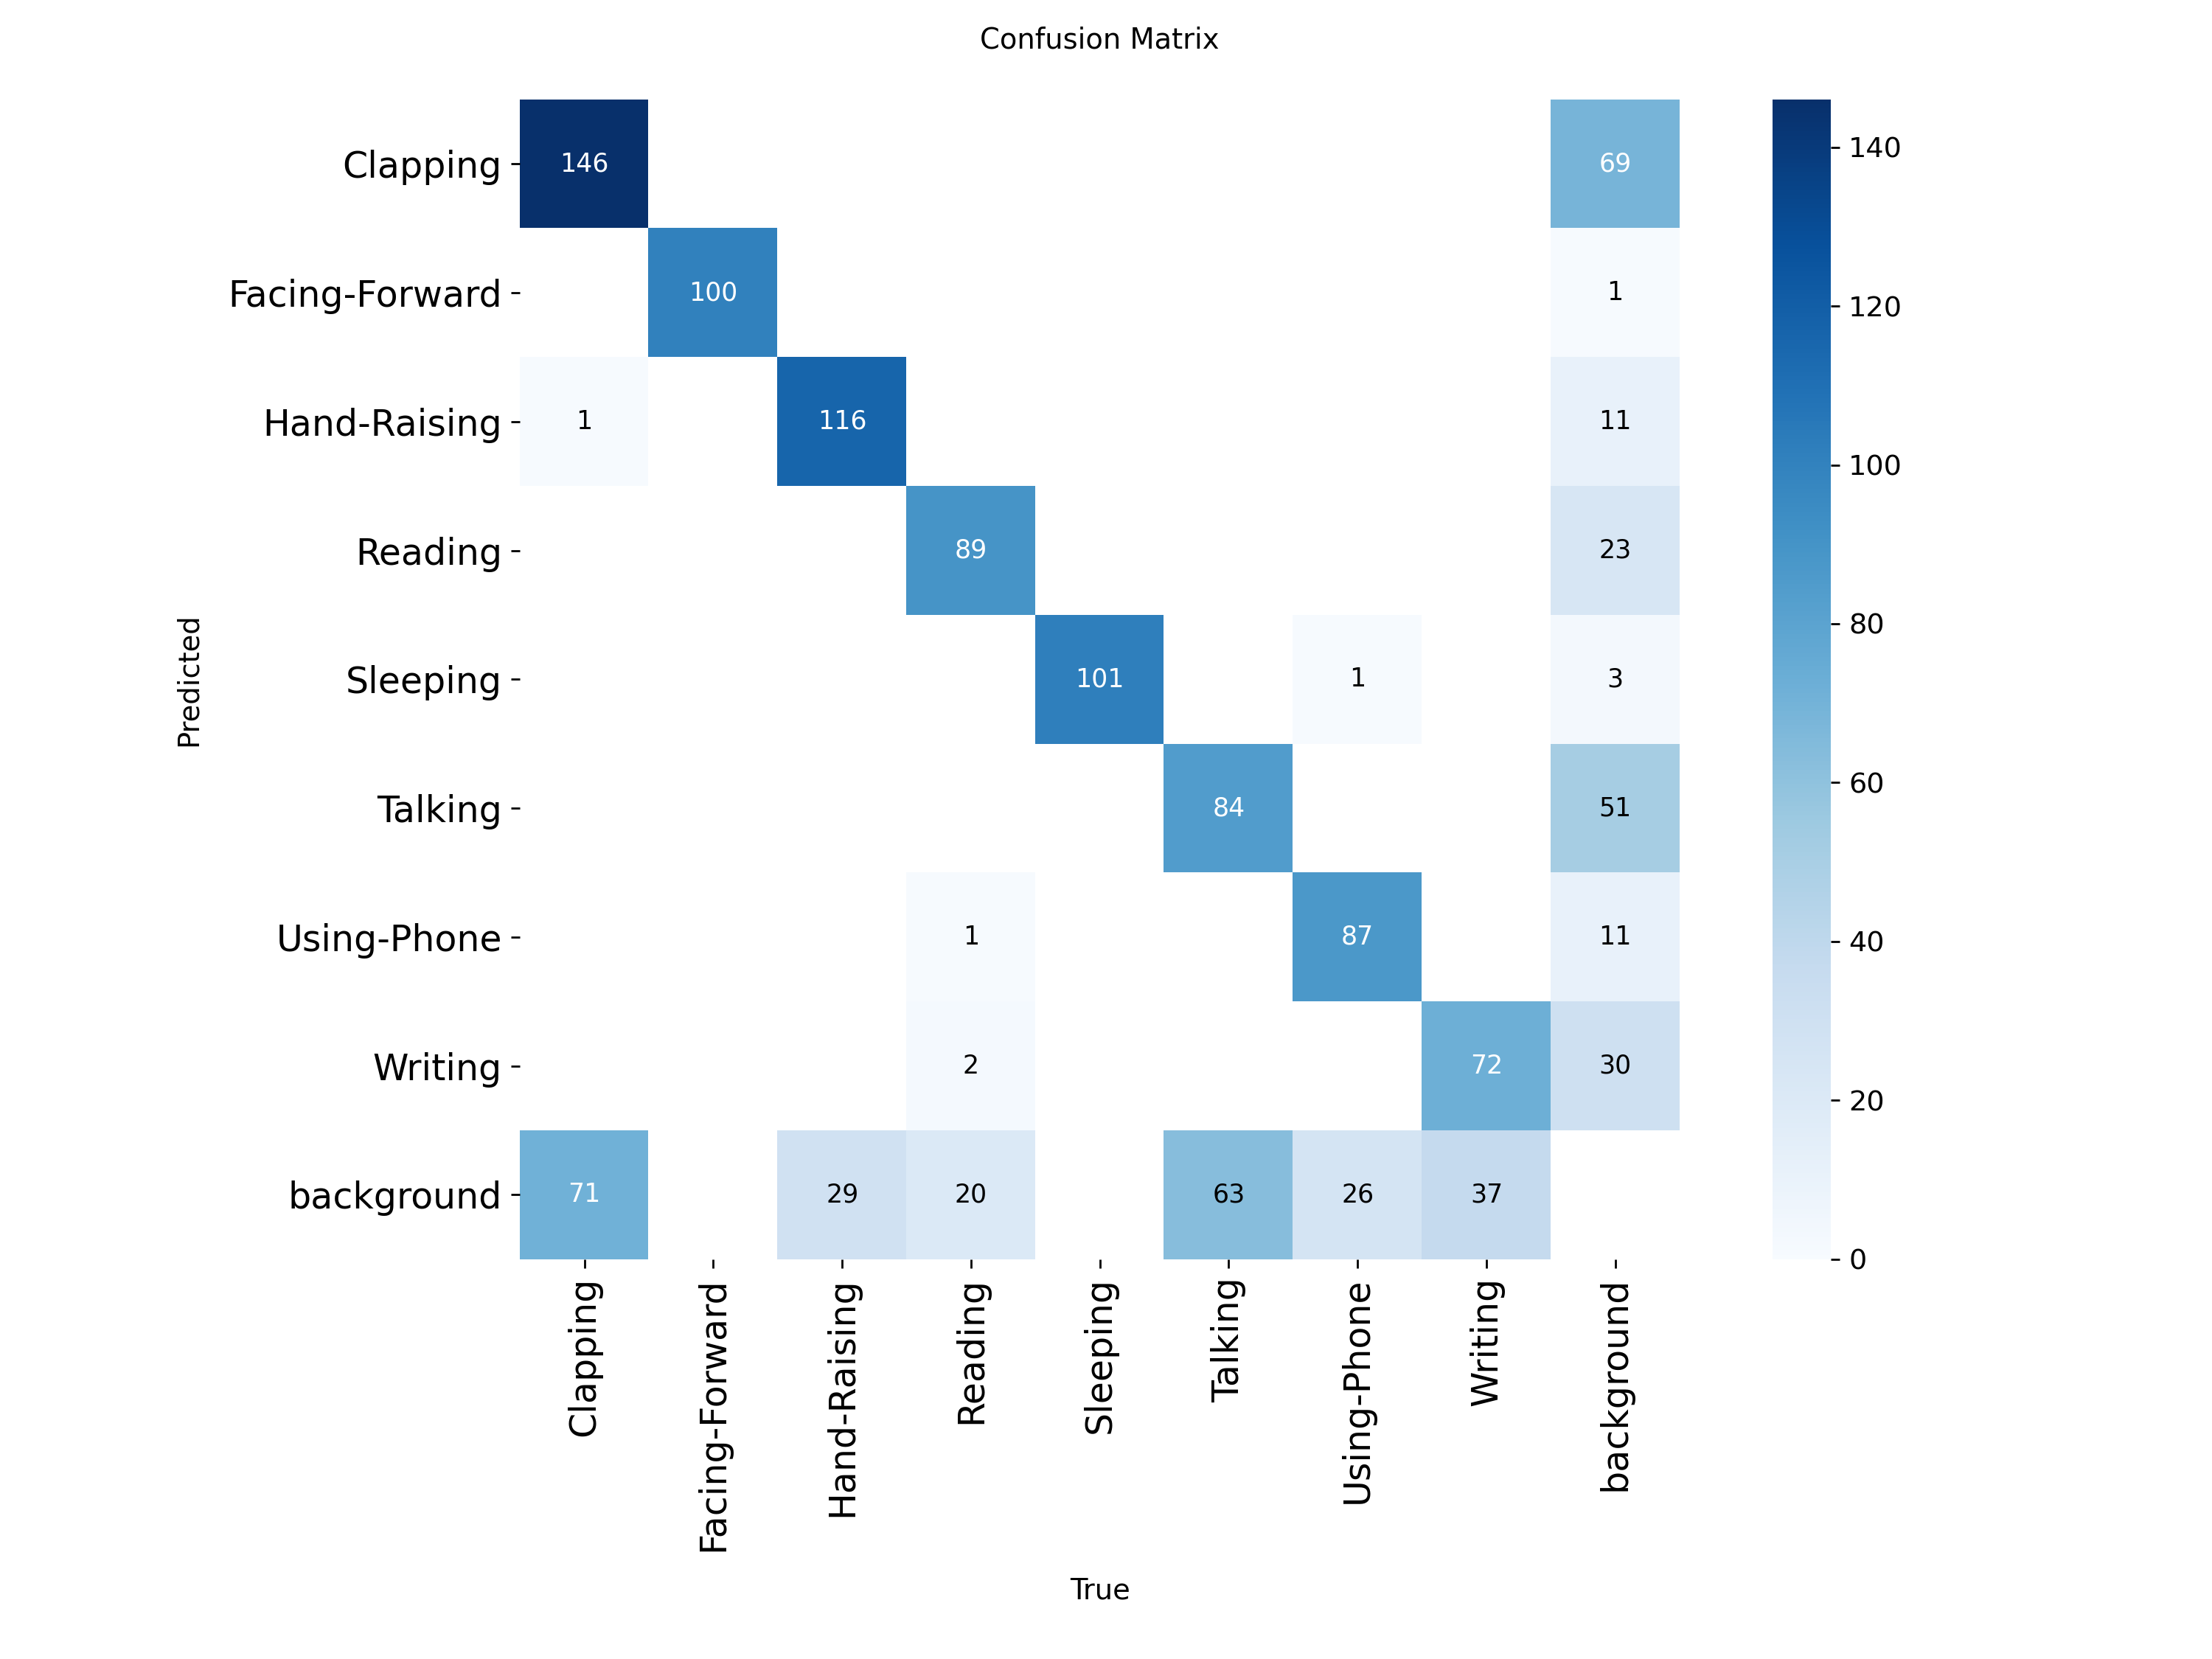

In [ ]:
from IPython.display import Image, display

display(Image(
    filename="/content/runs/detect/val-2/confusion_matrix.png",
    width=800
))

In [ ]:
from google.colab import files

files.download('/content/runs/detect/val-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>